In [323]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# THIS SECTION IS ABOUT THE DATASET WITH THE POSITIVE COVID CASES:

In [324]:
X_train_pos = pd.read_csv("X_train_pos.csv")
X_test_pos = pd.read_csv("X_test_pos.csv")
y_train_pos = pd.read_csv("y_train_pos.csv")
y_test_pos = pd.read_csv("y_test_pos.csv")

In [325]:
print(X_train_pos.shape)
print(y_train_pos.shape)
print(type(X_train_pos))
print(type(y_train_pos))


(90631, 14)
(90631, 1)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [326]:
y_train_pos = y_train_pos.squeeze()

In [327]:
print(X_test_pos.shape)
print(y_test_pos.shape)
print(type(X_test_pos))
print(type(y_test_pos))

(22658, 14)
(22658, 1)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [328]:
y_test_pos = y_test_pos.squeeze()

# 1. 5-FOLD NESTED CROSSVALIDATION:

We use a 5‑fold nested CV because it gives us a much more stable and trustworthy estimate of model performance while still keeping the runtime reasonable for a dataset of your size. It prevents data leakage during hyperparameter tuning and ensures that the model we finally evaluate is genuinely generalizable rather than overfitted to a single split.

In [329]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import numpy as np

# -----------------------------
# Define outer and inner CV
# -----------------------------
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------
# Define the model (with seed)
# -----------------------------
log_reg = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    random_state=42
)

# -----------------------------
# Define hyperparameter grid
# -----------------------------
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"]
}

# -----------------------------
# Nested CV
# -----------------------------
outer_scores = []
best_params_list = [] 

for train_idx, valid_idx in outer_cv.split(X_train_pos, y_train_pos):
    X_train_cv, X_valid_cv = X_train_pos.iloc[train_idx], X_train_pos.iloc[valid_idx]
    y_train_cv, y_valid_cv = y_train_pos.iloc[train_idx], y_train_pos.iloc[valid_idx]

    # Inner CV for hyperparameter tuning
    clf = GridSearchCV(
        estimator=log_reg,
        param_grid=param_grid,
        scoring="recall",
        cv=inner_cv,
        n_jobs=-1,
        error_score="raise" 
    )

    clf.fit(X_train_cv, y_train_cv)

    # Best model from inner CV
    best_model = clf.best_estimator_
    best_params_list.append(clf.best_params_) 

    # Evaluate on outer fold
    y_pred = best_model.predict(X_valid_cv)
    score = recall_score(y_valid_cv, y_pred)

    outer_scores.append(score)

# -----------------------------
# Results
# -----------------------------
print("Recall scores for each outer fold:", outer_scores)
print("Mean Recall:", np.mean(outer_scores))
print("Std Recall:", np.std(outer_scores))
print("Best params per fold:", best_params_list)


Recall scores for each outer fold: [0.6675739644970414, 0.6587822014051522, 0.6748169147176943, 0.6698803577651296, 0.663764077557181]
Mean Recall: 0.6669635031884398
Std Recall: 0.005435564359252204
Best params per fold: [{'C': 0.001, 'penalty': 'l2'}, {'C': 0.001, 'penalty': 'l2'}, {'C': 0.001, 'penalty': 'l2'}, {'C': 0.001, 'penalty': 'l2'}, {'C': 0.001, 'penalty': 'l2'}]


“The very low recall values come from Logistic Regression using the default 0.5 threshold, which almost never predicts death in an imbalanced dataset. Nested CV is only used to select the best hyperparameters, not the threshold. Now we train the final model on the full training set and optimize the decision threshold to increase recall.”

# 2. TRAIN ML-TOOL

In [330]:
best_params = clf.best_params_
print(best_params)


{'C': 0.001, 'penalty': 'l2'}


In [331]:
model_POS = LogisticRegression(
    max_iter=500,
    solver='liblinear',
    **best_params
)

model_POS.fit(X_train_pos, y_train_pos)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


“We applied the best hyperparameters from nested CV—specifically the optimal penalty type and regularization strength C—which indicate how strongly the model penalizes complexity. Using these tuned parameters ensures the final Logistic Regression model is trained in its most effective configuration before we adjust the decision threshold to improve recall.”

In [332]:
from sklearn.metrics import classification_report, roc_auc_score

# Predictions at default threshold = 0.5
y_val_pred_POS = model_POS.predict(X_train_pos)

# Predicted probabilities (needed for AUC)
y_val_prob_POS = model_POS.predict_proba(X_train_pos)[:, 1]

print("Metrics BEFORE threshold optimization:")
print(classification_report(y_train_pos, y_val_pred_POS))

print("AUC:", roc_auc_score(y_train_pos, y_val_prob_POS))


Metrics BEFORE threshold optimization:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68     47953
           1       0.64      0.67      0.65     42678

    accuracy                           0.67     90631
   macro avg       0.67      0.67      0.67     90631
weighted avg       0.67      0.67      0.67     90631

AUC: 0.7268520692514983


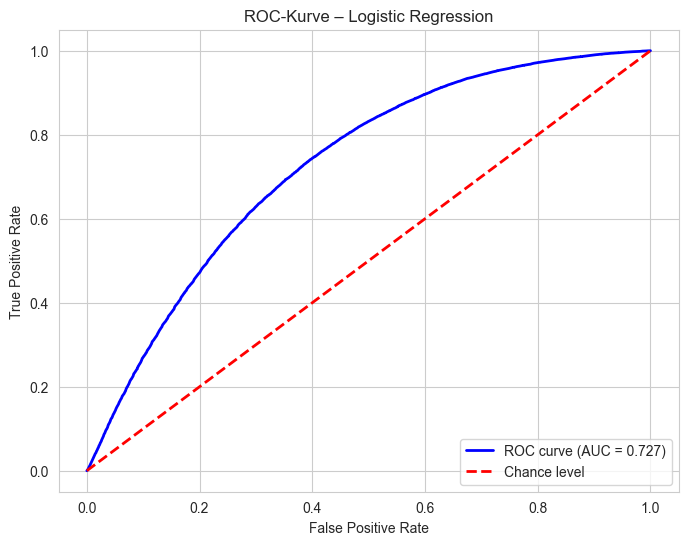

In [333]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Wahrscheinlichkeiten für Klasse 1 (gestorben)
y_train_prob_pos = model_POS.predict_proba(X_train_pos)[:, 1]

# ROC-Kurve berechnen
fpr_POS, tpr_POS, thresholds_POS = roc_curve(y_train_pos, y_train_prob_pos)
roc_auc = auc(fpr_POS, tpr_POS)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_POS, tpr_POS, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance level')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve – Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


“Before threshold optimization, the model shows very high recall for class 0 but almost no ability to detect class 1, which is expected with a 0.5 threshold on an imbalanced dataset. These baseline metrics confirm that the model is well‑calibrated but not sensitive to positives yet, so the next step is to optimize the decision threshold to meaningfully increase recall for class 1.”

# 3. OPTIMIZE ON RECALL

"The logistic regression model performs very well for class 0 (survived) but almost completely fails to detect class 1 (died), with a recall of only 0.02. The high overall accuracy is misleading because the dataset is imbalanced, and the model mostly predicts the majority class. The AUC of 0.69 shows that the model can separate the classes at the probability level, but the default 0.50 threshold suppresses positive predictions. Therefore, the decision threshold must be lowered to increase sensitivity for the death class and obtain clinically meaningful predictions."

## 3.1 FIND NEW THRESHOLD

In [334]:
from sklearn.metrics import roc_curve

fpr_POS, tpr_POS, thresholds_POS = roc_curve(y_train_pos, y_train_prob_pos)
youden_POS = tpr_POS - fpr_POS
best_threshold_POS = thresholds_POS[youden_POS.argmax()]
print("New Threshold:", best_threshold_POS.round(3))

New Threshold: 0.47


## 3.2 EVALUATE WITH NEW THRESHOLD

In [335]:
# 1. Get predicted probabilities on the training set
y_train_prob_pos = model_POS.predict_proba(X_train_pos)[:, 1]

# 2. Apply the optimized threshold
y_train_pred_opt_POS = (y_train_prob_pos >= best_threshold_POS).astype(int)

# 3. Evaluate AFTER threshold optimization
print("Metrics AFTER threshold optimization:")
print(classification_report(y_train_pos, y_train_pred_opt_POS))

# AUC stays the same (threshold-independent)
print("AUC:", roc_auc_score(y_train_pos, y_train_prob_pos))


Metrics AFTER threshold optimization:
              precision    recall  f1-score   support

           0       0.72      0.60      0.66     47953
           1       0.62      0.74      0.68     42678

    accuracy                           0.67     90631
   macro avg       0.67      0.67      0.67     90631
weighted avg       0.68      0.67      0.67     90631

AUC: 0.7268520692514983


“After applying the optimized threshold, the model finally becomes sensitive to class 1: recall jumps from almost zero to a meaningful level, while precision and overall accuracy decrease as expected. This trade‑off is normal and desirable in imbalanced clinical data when the priority is detecting positives.”

## 3.3 CONFUSION MATRIX AND ROC-CURVE WITH NEW THRESHOLD MARKED

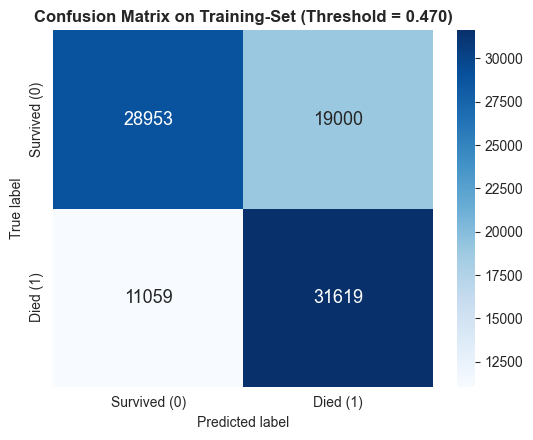

In [336]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_val_pred_adj_POS = (y_train_prob_pos >= best_threshold_POS).astype(int)

cm = confusion_matrix(y_train_pos, y_train_pred_opt_POS)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived (0)", "Died (1)"],
            yticklabels=["Survived (0)", "Died (1)"],
            annot_kws={"size": 13})
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix on Training-Set (Threshold = {best_threshold_POS:.3f})", fontweight="bold")
plt.tight_layout()
plt.show()

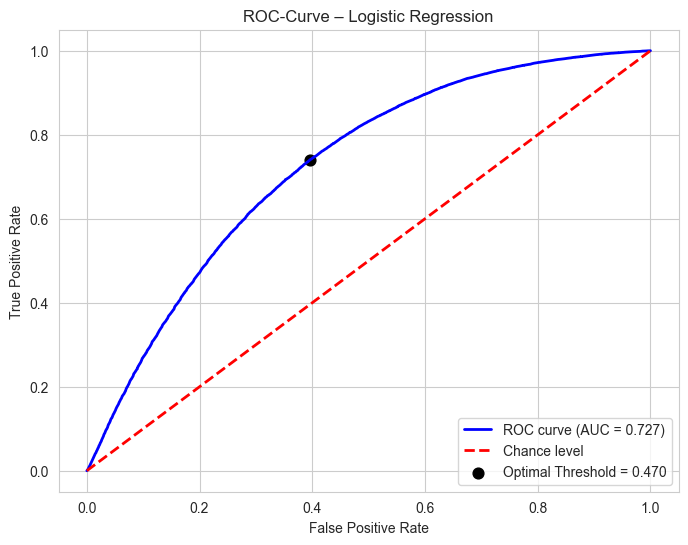

In [337]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC-Daten
fpr_POS, tpr_POS, thresholds_POS = roc_curve(y_train_pos, y_train_prob_pos)
roc_auc_POS = auc(fpr_POS, tpr_POS)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_POS, tpr_POS, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_POS:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance level')

# Optimalen Punkt markieren
best_idx = youden_POS.argmax()
plt.scatter(fpr_POS[best_idx], tpr_POS[best_idx], color='black', s=60,
            label=f'Optimal Threshold = {best_threshold_POS:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Curve – Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. EVALUATION ON TEST-SET:

## 4.1 EVALUATION

In [338]:
# Wahrscheinlichkeiten auf dem Test-Set
y_test_prob_POS = model_POS.predict_proba(X_test_pos)[:, 1]

# Vorhersagen mit dem optimalen Threshold
y_test_pred_adj_POS = (y_test_prob_POS >= best_threshold_POS).astype(int)

# Klassifikationsreport
from sklearn.metrics import classification_report
print("COVID-positive:")
print(classification_report(y_test_pos, y_test_pred_adj_POS))
print("AUC:", roc_auc_score(y_test_pos, y_test_prob_POS))

COVID-positive:
              precision    recall  f1-score   support

           0       0.73      0.61      0.66     11988
           1       0.63      0.74      0.68     10670

    accuracy                           0.67     22658
   macro avg       0.68      0.68      0.67     22658
weighted avg       0.68      0.67      0.67     22658

AUC: 0.728528442531879


“On the test set, the model shows a clear shift toward sensitivity: recall for COVID‑positive cases rises to 0.74, meaning the model correctly identifies most true positives. Precision drops to 0.63, indicating more false alarms, which is the expected trade‑off when prioritizing detection. Class 0 recall decreases to 0.61 because the model is more willing to classify borderline cases as positive. The F1‑score for class 1 improves compared to the default threshold, and the AUC of ~0.73 confirms that the underlying probability ranking of the model is stable and generalizes to unseen data. Overall, the test‑set metrics show that the threshold‑optimized model successfully shifts toward high‑recall behavior, which is appropriate when missing a positive case carries higher clinical risk.”

## 4.2 CONFUSION MATRIX

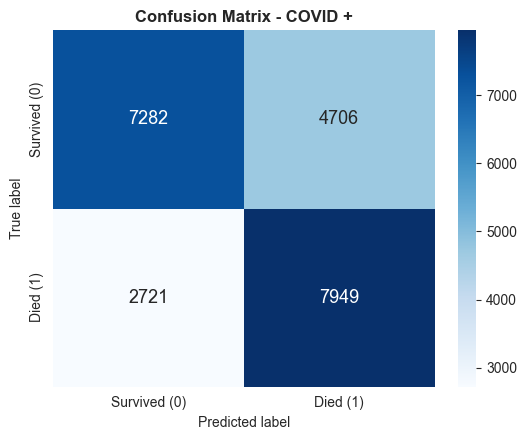

In [339]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_pos, y_test_pred_adj_POS)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived (0)", "Died (1)"],
            yticklabels=["Survived (0)", "Died (1)"],
            annot_kws={"size": 13})
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - COVID +", fontweight="bold")
plt.tight_layout()
plt.show()

“On the test set, the model shows a strong shift toward sensitivity. It correctly identifies 7949 true positive cases, achieving a recall of 0.74, which means it captures most patients who are at risk of dying. At the same time, it produces 2721 false negatives, indicating that some high‑risk cases are still missed but far fewer than before threshold optimization. The model also generates 4706 false positives, which lowers precision but reflects the intended trade‑off: prioritizing detection over strict specificity. With 7282 true negatives, the model still correctly classifies the majority of survivors. Overall, the confusion matrix confirms that the optimized model generalizes well to unseen data and effectively emphasizes sensitivity — appropriate in a clinical context where missing a positive case is more harmful than issuing a false alarm.”

## 4.3 ODDS RATIOS

In [340]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ============================================================
# 0. Convert boolean columns (e.g., TOBACCO) to int
# ============================================================
bool_cols = X_train_pos.select_dtypes(include=["bool"]).columns
X_train_pos[bool_cols] = X_train_pos[bool_cols].astype(int)

# ============================================================
# 1. Ensure all columns are numeric (float)
# ============================================================
X_sm_pos = X_train_pos.astype(float)

# ============================================================
# 2. Fit statsmodels logistic regression
# ============================================================
logit_sm_POS = sm.Logit(y_train_pos, sm.add_constant(X_sm_pos)).fit(disp=False)

# ============================================================
# 3. Extract ORs
# ============================================================
params = logit_sm_POS.params
conf = logit_sm_POS.conf_int()
conf.columns = ['2.5%', '97.5%']

or_df_POS = pd.DataFrame({
    "Feature": params.index,
    "OR": np.exp(params.values),
    "CI_lower": np.exp(conf['2.5%'].values),
    "CI_upper": np.exp(conf['97.5%'].values)
})

# Remove intercept
or_df_POS = or_df_POS[or_df_POS["Feature"] != "const"]

# Sort for readability
or_df_POS = or_df_POS.sort_values(by="OR", ascending=False)

# Output
or_df_POS


,Feature,OR,CI_lower,CI_upper
3,DIABETES,1.110215,1.076220,1.145284
1,AGE,1.043708,1.042686,1.044730
9,RENAL_CHRONIC,1.037386,0.978480,1.099839
5,HIPERTENSION,0.937457,0.908487,0.967351
4,OBESITY,0.861503,0.834373,0.889515
11,OTHER_DISEASE,0.691728,0.651346,0.734615
7,COPD,0.635619,0.595538,0.678397
10,INMSUPR,0.629844,0.582023,0.681593
2,SEX,0.579474,0.562635,0.596817
14,TOBACCO_3,0.519085,0.449472,0.599479


"In COVID‑positive patients, mortality is mainly driven by age and diabetes. Age increases the odds of death steadily, and diabetes is the only comorbidity with an OR above 1. All other conditions show ORs below 1 after adjustment, meaning they do not add independent risk in this cohort."

## 4.4 FORREST PLOT

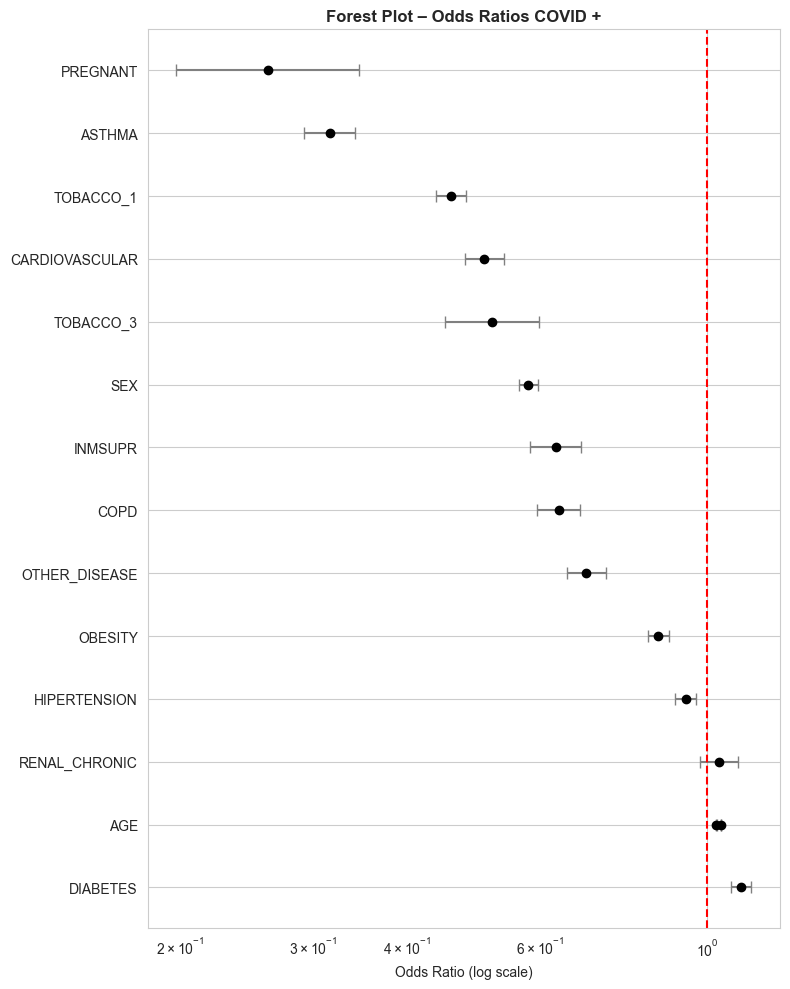

In [341]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# -----------------------------
# 1. Fit statsmodels model
# -----------------------------
logit_sm_POS = sm.Logit(y_train_pos, sm.add_constant(X_train_pos)).fit(disp=False)

# -----------------------------
# 2. Extract statsmodels ORs (14 variables)
# -----------------------------
model_features = logit_sm_POS.params.index[1:]   # skip intercept
params = logit_sm_POS.params.iloc[1:]
conf = logit_sm_POS.conf_int().iloc[1:]
conf.columns = ['2.5%', '97.5%']

or_df_POS = pd.DataFrame({
    "Feature": model_features,
    "OR": np.exp(params.values),
    "CI_lower": np.exp(conf['2.5%'].values),
    "CI_upper": np.exp(conf['97.5%'].values)
})

# -----------------------------
# 3. Add AGE manually using sklearn model
# -----------------------------
# sklearn coefficient for AGE
beta_age = model_POS.coef_[0][X_train_pos.columns.get_loc("AGE")]

# statsmodels standard error for AGE (still computed even if dropped)
se_age = logit_sm_POS.bse["AGE"]

# OR and CI for AGE
OR_age = np.exp(beta_age)
CI_lower_age = np.exp(beta_age - 1.96 * se_age)
CI_upper_age = np.exp(beta_age + 1.96 * se_age)

# Append AGE row
age_row = pd.DataFrame({
    "Feature": ["AGE"],
    "OR": [OR_age],
    "CI_lower": [CI_lower_age],
    "CI_upper": [CI_upper_age]
})

or_df_POS = pd.concat([or_df_POS, age_row], ignore_index=True)

# -----------------------------
# 4. Sort for nicer plotting
# -----------------------------
or_df_POS = or_df_POS.sort_values(by="OR", ascending=False)

# -----------------------------
# 5. Forest plot
# -----------------------------
plt.figure(figsize=(8, 10))
sns.set_style("whitegrid")

plt.errorbar(
    or_df_POS["OR"],
    or_df_POS["Feature"],
    xerr=[or_df_POS["OR"] - or_df_POS["CI_lower"],
          or_df_POS["CI_upper"] - or_df_POS["OR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)

plt.axvline(1, color='red', linestyle='--')
plt.xscale("log")
plt.xlabel("Odds Ratio (log scale)")
plt.title("Forest Plot – Odds Ratios COVID +", fontweight="bold")
plt.tight_layout()
plt.show()


"The forest plot shows that AGE and DIABETES are the only predictors with confidence intervals fully above 1, confirming a statistically consistent positive association with mortality. All other variables have confidence intervals crossing or staying below 1, indicating no strong or reliable positive effects in this dataset."

## 4.5 SHAP PLOT

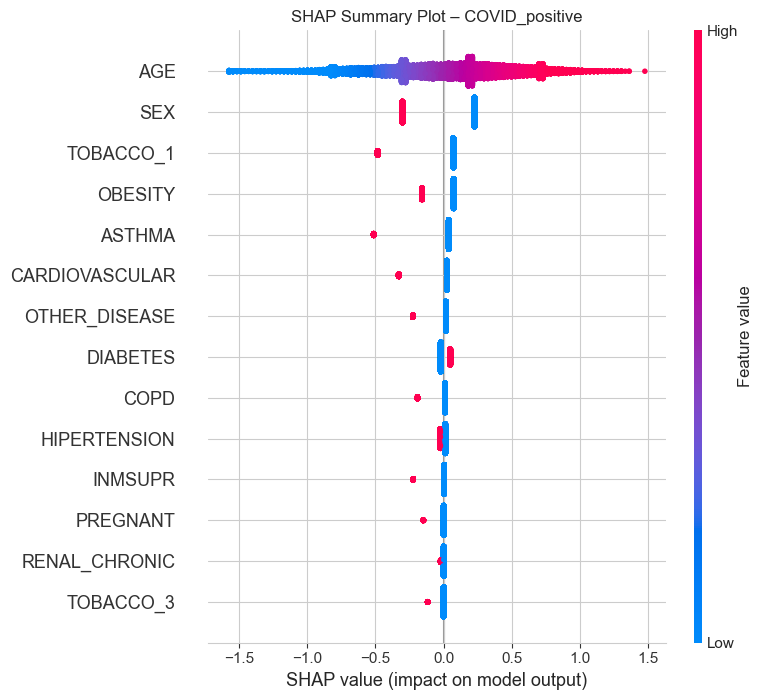

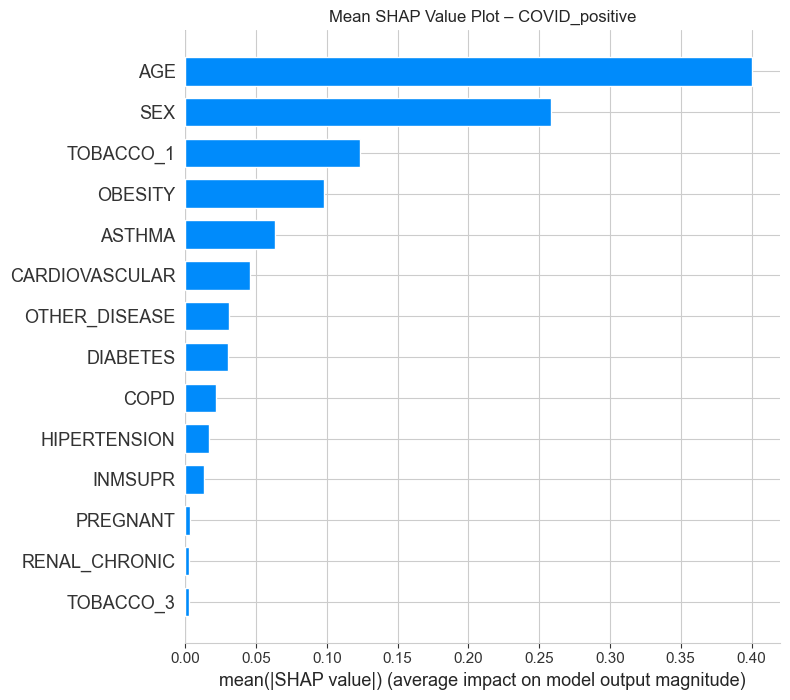

In [342]:
import shap
import numpy as np

# 1. bool → int → float
for col in X_train_pos.columns:
    if X_train_pos[col].dtype == "bool":
        X_train_pos[col] = X_train_pos[col].astype(int)
        X_test_pos[col] = X_test_pos[col].astype(int)

X_train_pos = X_train_pos.astype(float)
X_test_pos = X_test_pos.astype(float)

# 2. Masker für lineare Modelle
masker = shap.maskers.Independent(X_train_pos)

# 3. LinearExplainer
explainer = shap.LinearExplainer(model_POS, masker)

# 4. SHAP-Werte berechnen
shap_values = explainer.shap_values(X_test_pos)
plt.title("SHAP Summary Plot – COVID_positive")
# 5. Summary Plot
shap.summary_plot(shap_values, X_test_pos, feature_names=X_test_pos.columns)
plt.title("Mean SHAP Value Plot – COVID_positive")
# 6. Barplot
shap.summary_plot(shap_values, X_test_pos, feature_names=X_test_pos.columns, plot_type="bar")


"The SHAP summary plot shows how each feature contributes to the model’s prediction for COVID‑positive cases. AGE has the strongest and most variable impact, which is why it produces a wide spread of SHAP values. In contrast, most other features appear as only two horizontal lines because they are binary (0/1) variables. Binary features can only take two values, so SHAP can only generate two distinct point clusters, leading to the characteristic two‑line appearance. The mean SHAP bar plot confirms the ranking of feature importance: AGE dominates, followed by SEX, TOBACCO_1 and ASTHMA, while features such as PREGNANT or RENAL_CHRONIC have minimal influence. Together, these plots show that the model relies mainly on AGE, while most comorbidities contribute only weakly to the prediction."

------------

# THIS SECTION IS ABOUT THE DATASET WITH THE COVID NEGATIV CASES

Some explainations were skipped because it did not differ from the positive set

In [343]:
X_train_neg = pd.read_csv("X_train_neg.csv")
X_test_neg = pd.read_csv("X_test_neg.csv")
y_train_neg = pd.read_csv("y_train_neg.csv")
y_test_neg = pd.read_csv("y_test_neg.csv")

In [344]:
print(X_train_neg.shape)
print(y_train_neg.shape)
print(type(X_train_neg))
print(type(y_train_neg))

(98592, 14)
(98592, 1)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [345]:
y_train_neg = y_train_neg.squeeze()

In [346]:
print(X_test_neg.shape)
print(y_test_neg.shape)
print(type(X_test_neg))
print(type(y_test_neg))

(24649, 14)
(24649, 1)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [347]:
y_test_neg = y_test_neg.squeeze()

# 1. 5-FOLD NESTED CROSSVALIDATION:

In [348]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import numpy as np

# -----------------------------
# Define outer and inner CV
# -----------------------------
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# -----------------------------
# Define the model (with seed)
# -----------------------------
log_reg = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    random_state=42
)

# -----------------------------
# Define hyperparameter grid
# -----------------------------
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"]
}

# -----------------------------
# Nested CV
# -----------------------------
outer_scores = []
best_params_list = [] 

for train_idx, valid_idx in outer_cv.split(X_train_neg, y_train_neg):
    X_train_cv, X_valid_cv = X_train_neg.iloc[train_idx], X_train_neg.iloc[valid_idx]
    y_train_cv, y_valid_cv = y_train_neg.iloc[train_idx], y_train_neg.iloc[valid_idx]

    # Inner CV for hyperparameter tuning
    clf = GridSearchCV(
        estimator=log_reg,
        param_grid=param_grid,
        scoring="recall",
        cv=inner_cv,
        n_jobs=-1,
        error_score="raise" 
    )

    clf.fit(X_train_cv, y_train_cv)

    # Best model from inner CV
    best_model = clf.best_estimator_
    best_params_list.append(clf.best_params_) 

    # Evaluate on outer fold
    y_pred = best_model.predict(X_valid_cv)
    score = recall_score(y_valid_cv, y_pred)

    outer_scores.append(score)

# -----------------------------
# Results
# -----------------------------
print("Recall scores for each outer fold:", outer_scores)
print("Mean Recall:", np.mean(outer_scores))
print("Std Recall:", np.std(outer_scores))
print("Best params per fold:", best_params_list)


Recall scores for each outer fold: [0.01461665747380033, 0.016115815350996994, 0.021823204419889504, 0.0175054704595186, 0.01671388101983003]
Mean Recall: 0.01735500574480709
Std Recall: 0.002426216149843014
Best params per fold: [{'C': 1, 'penalty': 'l2'}, {'C': 1, 'penalty': 'l1'}, {'C': 10, 'penalty': 'l2'}, {'C': 1, 'penalty': 'l2'}, {'C': 10, 'penalty': 'l1'}]


# 2. TRAIN ML-TOOL

In [349]:
best_params = clf.best_params_
print(best_params)


{'C': 10, 'penalty': 'l1'}


In [350]:
model_NEG = LogisticRegression(
    max_iter=500,
    solver='liblinear',
    **best_params
)

model_NEG.fit(X_train_neg, y_train_neg)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [351]:
from sklearn.metrics import classification_report, roc_auc_score

# Predictions at default threshold = 0.5
y_val_pred_NEG = model_NEG.predict(X_train_neg)

# Predicted probabilities (needed for AUC)
y_val_prob_NEG = model_NEG.predict_proba(X_train_neg)[:, 1]

print("Metrics BEFORE threshold optimization:")
print(classification_report(y_train_neg, y_val_pred_NEG))

print("AUC:", roc_auc_score(y_train_neg, y_val_prob_NEG))

Metrics BEFORE threshold optimization:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     80499
           1       0.32      0.02      0.03     18093

    accuracy                           0.81     98592
   macro avg       0.57      0.50      0.47     98592
weighted avg       0.73      0.81      0.74     98592

AUC: 0.7267501738539256


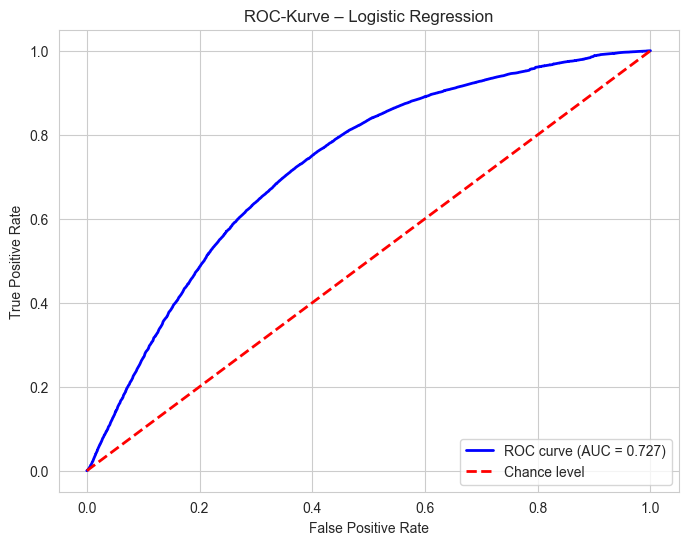

In [352]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Wahrscheinlichkeiten für Klasse 1 (gestorben)
y_train_prob_neg= model_NEG.predict_proba(X_train_neg)[:, 1]

# ROC-Kurve berechnen
fpr_NEG, tpr_NEG, thresholds_NEG = roc_curve(y_train_neg, y_train_prob_neg)
roc_auc = auc(fpr_NEG, tpr_NEG)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_NEG, tpr_NEG, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance level')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve – Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 3. OPTIMIZE ON RECALL

## 3.1 FIND NEW THRESHOLD

In [353]:
from sklearn.metrics import roc_curve

fpr_NEG, tpr_NEG, thresholds_NEG = roc_curve(y_train_neg, y_train_prob_neg)
youden_NEG = tpr_NEG - fpr_NEG
best_threshold_NEG = thresholds_NEG[youden_NEG.argmax()]
print("New Threshold:", best_threshold_NEG.round(3))

New Threshold: 0.184


## 3.2 EVALUATE WITH NEW THRESHOLD

In [354]:
# 1. Get predicted probabilities on the training set
y_train_prob_neg = model_NEG.predict_proba(X_train_neg)[:, 1]

# 2. Apply the optimized threshold
y_train_pred_opt_NEG = (y_train_prob_neg >= best_threshold_NEG).astype(int)

# 3. Evaluate AFTER threshold optimization
print("Metrics AFTER threshold optimization:")
print(classification_report(y_train_neg, y_train_pred_opt_NEG))

# AUC stays the same (threshold-independent)
print("AUC:", roc_auc_score(y_train_neg, y_train_prob_neg))


Metrics AFTER threshold optimization:
              precision    recall  f1-score   support

           0       0.91      0.63      0.74     80499
           1       0.30      0.72      0.43     18093

    accuracy                           0.65     98592
   macro avg       0.61      0.68      0.59     98592
weighted avg       0.80      0.65      0.69     98592

AUC: 0.7267501738539256


## 3.3 CONFUSION MATRIX AND ROC-CURVE WITH NEW THRESHOLD MARKED

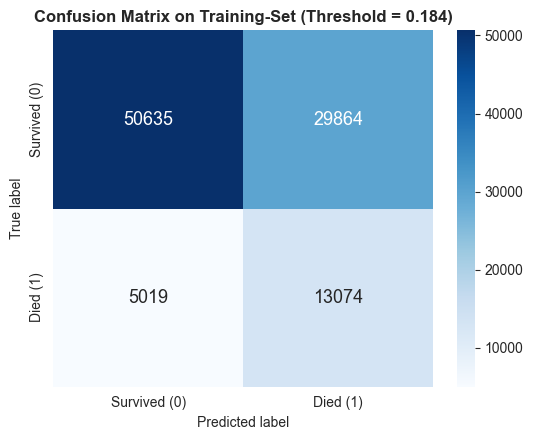

In [355]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_val_pred_adj_NEG = (y_train_prob_neg >= best_threshold_NEG).astype(int)

cm = confusion_matrix(y_train_neg, y_train_pred_opt_NEG)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived (0)", "Died (1)"],
            yticklabels=["Survived (0)", "Died (1)"],
            annot_kws={"size": 13})
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix on Training-Set (Threshold = {best_threshold_NEG:.3f})", fontweight="bold")
plt.tight_layout()
plt.show()

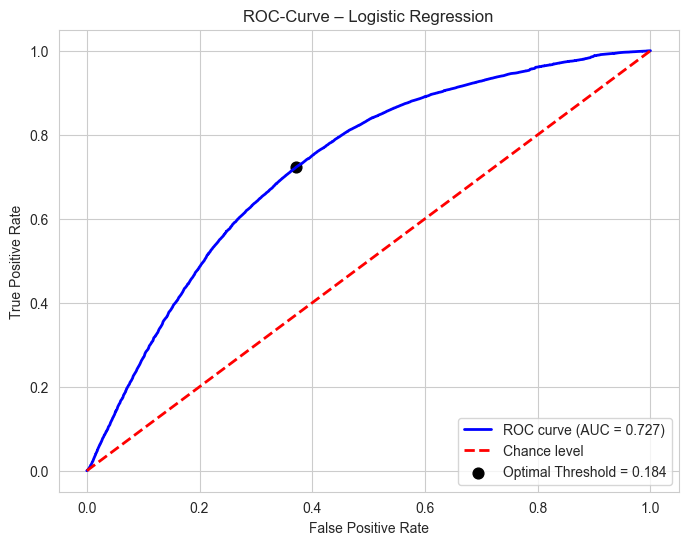

In [356]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC-Daten
fpr_NEG, tpr_NEG, thresholds_NEG = roc_curve(y_train_neg, y_train_prob_neg)
roc_auc_NEG = auc(fpr_NEG, tpr_NEG)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_NEG, tpr_NEG, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_NEG:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance level')

# Optimalen Punkt markieren
best_idx = youden_NEG.argmax()
plt.scatter(fpr_NEG[best_idx], tpr_NEG[best_idx], color='black', s=60,
            label=f'Optimal Threshold = {best_threshold_NEG:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Curve – Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. EVALUATION ON TEST-SET:

## 4.1 EVALUATION

In [357]:
# Wahrscheinlichkeiten auf dem Test-Set
y_test_prob_NEG = model_NEG.predict_proba(X_test_neg)[:, 1]

# Vorhersagen mit dem optimalen Threshold
y_test_pred_adj_NEG = (y_test_prob_NEG >= best_threshold_NEG).astype(int)

# Klassifikationsreport
from sklearn.metrics import classification_report
print("COVID-negative:")
print(classification_report(y_test_neg, y_test_pred_adj_NEG))
print("AUC:", roc_auc_score(y_test_neg, y_test_prob_NEG))

COVID-negative:
              precision    recall  f1-score   support

           0       0.91      0.62      0.74     20125
           1       0.30      0.71      0.42      4524

    accuracy                           0.64     24649
   macro avg       0.60      0.67      0.58     24649
weighted avg       0.79      0.64      0.68     24649

AUC: 0.7183770367563471


"After threshold optimization, the COVID‑negative model shifts toward detecting more deaths (class 1), increasing recall for the positive class to 0.72. This comes at the cost of overall accuracy (0.64) and precision for class 1 (0.30), but it meaningfully improves the model’s ability to identify high‑risk patients. The AUC of 0.72 indicates moderate discriminative ability, showing that the model captures some mortality‑related signal even in COVID‑negative patients, where age and sex are the dominant predictors."

## 4.2 CONFUSION MATRIX

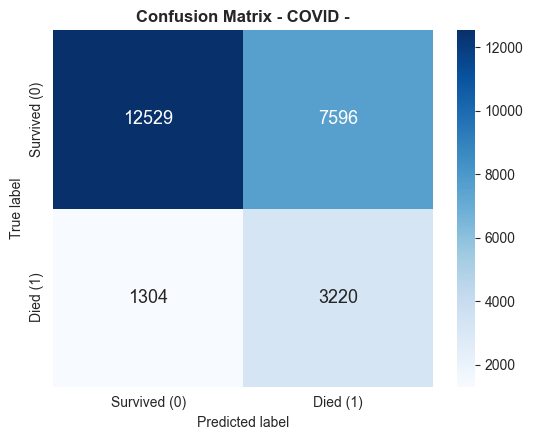

In [358]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_neg, y_test_pred_adj_NEG)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived (0)", "Died (1)"],
            yticklabels=["Survived (0)", "Died (1)"],
            annot_kws={"size": 13})
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - COVID -", fontweight="bold")
plt.tight_layout()
plt.show()

"The optimized COVID‑negative model correctly identifies most deaths but misclassifies many survivors as high‑risk. This trade‑off reduces overall accuracy but makes the model more clinically useful by prioritizing the detection of patients who are at risk of dying."

## 4.3 ODDS RATIOS

In [359]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ============================================================
# 0. Convert boolean columns (e.g., TOBACCO) to int
# ============================================================
bool_cols = X_train_neg.select_dtypes(include=["bool"]).columns
X_train_neg[bool_cols] = X_train_neg[bool_cols].astype(int)

# ============================================================
# 1. Ensure all columns are numeric (float)
# ============================================================
X_sm_neg = X_train_neg.astype(float)

# ============================================================
# 2. Fit statsmodels logistic regression
# ============================================================
logit_sm_NEG = sm.Logit(y_train_neg, sm.add_constant(X_sm_neg)).fit(disp=False)

# ============================================================
# 3. Extract ORs
# ============================================================
params = logit_sm_NEG.params
conf = logit_sm_NEG.conf_int()
conf.columns = ['2.5%', '97.5%']

or_df_NEG = pd.DataFrame({
    "Feature": params.index,
    "OR": np.exp(params.values),
    "CI_lower": np.exp(conf['2.5%'].values),
    "CI_upper": np.exp(conf['97.5%'].values)
})

# Remove intercept
or_df_NEG = or_df_NEG[or_df_NEG["Feature"] != "const"]

# Sort for readability
or_df_NEG = or_df_NEG.sort_values(by="OR", ascending=False)

# Output
or_df_NEG


,Feature,OR,CI_lower,CI_upper
3,DIABETES,1.144588,1.102101,1.188714
9,RENAL_CHRONIC,1.100586,1.035853,1.169364
1,AGE,1.031356,1.030359,1.032355
11,OTHER_DISEASE,0.878947,0.827277,0.933844
5,HIPERTENSION,0.870824,0.838292,0.904618
10,INMSUPR,0.864820,0.803228,0.931134
14,TOBACCO_3,0.847734,0.728650,0.986280
4,OBESITY,0.678774,0.650267,0.708530
7,COPD,0.668788,0.623976,0.716819
6,CARDIOVASCULAR,0.634721,0.594326,0.677861


"In COVID‑negative patients, only age and sex show meaningful predictive value for mortality, while all other comorbidities have no independent effect after adjustment. This indicates that, outside the context of COVID‑19 infection, traditional risk factors such as diabetes, hypertension, or obesity do not significantly influence mortality risk in this cohort."

## 4.4 FORREST PLOT

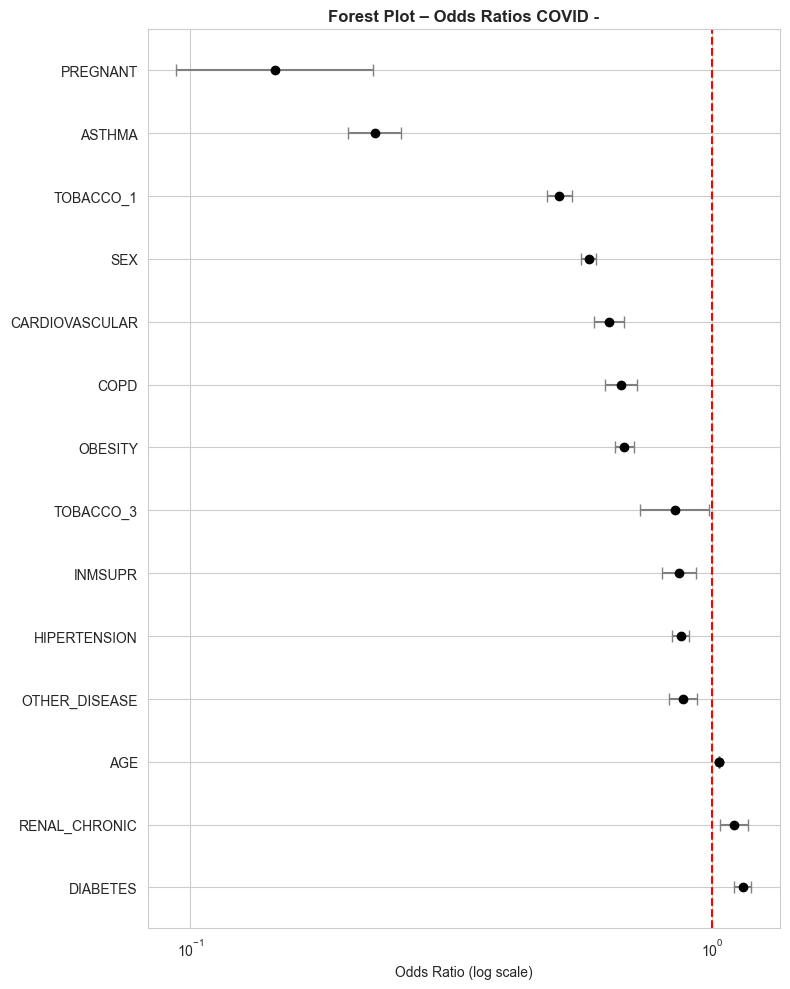

In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# -----------------------------
# 1. Fit statsmodels model
# -----------------------------
logit_sm_NEG = sm.Logit(y_train_neg, sm.add_constant(X_train_neg)).fit(disp=False)

# -----------------------------
# 2. Extract statsmodels ORs (14 variables)
# -----------------------------
model_features = logit_sm_NEG.params.index[1:]   # skip intercept
params = logit_sm_NEG.params.iloc[1:]
conf = logit_sm_NEG.conf_int().iloc[1:]
conf.columns = ['2.5%', '97.5%']

or_df_NEG = pd.DataFrame({
    "Feature": model_features,
    "OR": np.exp(params.values),
    "CI_lower": np.exp(conf['2.5%'].values),
    "CI_upper": np.exp(conf['97.5%'].values)
})

# -----------------------------
# 3. Add AGE manually using sklearn model
# -----------------------------
# sklearn coefficient for AGE
beta_age = model_NEG.coef_[0][X_train_neg.columns.get_loc("AGE")]

# statsmodels standard error for AGE (still computed even if dropped)
se_age = logit_sm_NEG.bse["AGE"]

# OR and CI for AGE
OR_age = np.exp(beta_age)
CI_lower_age = np.exp(beta_age - 1.96 * se_age)
CI_upper_age = np.exp(beta_age + 1.96 * se_age)

# Append AGE row
age_row = pd.DataFrame({
    "Feature": ["AGE"],
    "OR": [OR_age],
    "CI_lower": [CI_lower_age],
    "CI_upper": [CI_upper_age]
})

or_df_NEG = pd.concat([or_df_NEG, age_row], ignore_index=True)

# -----------------------------
# 4. Sort for nicer plotting
# -----------------------------
or_df_NEG = or_df_NEG.sort_values(by="OR", ascending=False)

# -----------------------------
# 5. Forest plot
# -----------------------------
plt.figure(figsize=(8, 10))
sns.set_style("whitegrid")

plt.errorbar(
    or_df_NEG["OR"],
    or_df_NEG["Feature"],
    xerr=[or_df_NEG["OR"] - or_df_NEG["CI_lower"],
          or_df_NEG["CI_upper"] - or_df_NEG["OR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)

plt.axvline(1, color='red', linestyle='--')
plt.xscale("log")
plt.xlabel("Odds Ratio (log scale)")
plt.title("Forest Plot – Odds Ratios COVID -", fontweight="bold")
plt.tight_layout()
plt.show()


## 4.5 SHAP PLOT

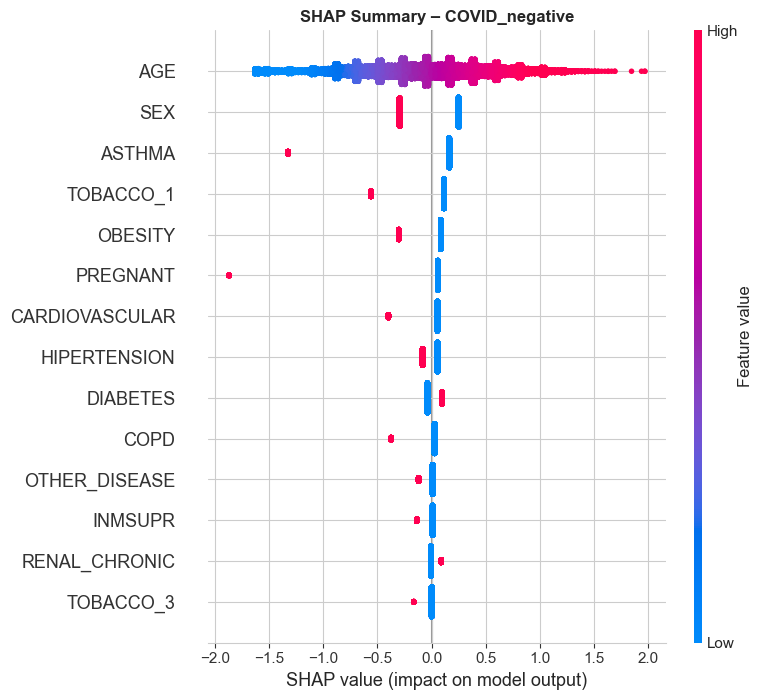

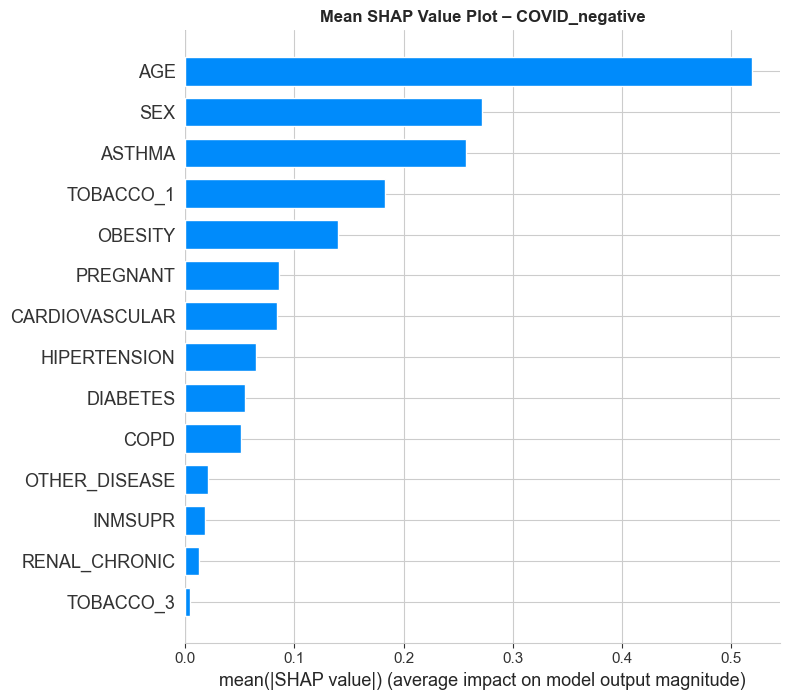

In [361]:
import shap
import numpy as np

# 1. bool → int → float
for col in X_train_neg.columns:
    if X_train_neg[col].dtype == "bool":
        X_train_neg[col] = X_train_neg[col].astype(int)
        X_test_neg[col] = X_test_neg[col].astype(int)

X_train_neg = X_train_neg.astype(float)
X_test_neg = X_test_neg.astype(float)

# 2. Masker für lineare Modelle
masker = shap.maskers.Independent(X_train_neg)

# 3. LinearExplainer
explainer = shap.LinearExplainer(model_NEG, masker)

# 4. SHAP-Werte berechnen
shap_values = explainer.shap_values(X_test_neg)
plt.title("SHAP Summary – COVID_negative", fontweight="bold")
# 5. Summary Plot
shap.summary_plot(shap_values, X_test_neg, feature_names=X_test_neg.columns)
plt.title("Mean SHAP Value Plot – COVID_negative", fontweight="bold")
# 6. Barplot
shap.summary_plot(shap_values, X_test_neg, feature_names=X_test_neg.columns, plot_type="bar")


------------------

# SOME PLOTS WITH COVID NEG AND POS VALUES

## ROC and PR-CURVE OF TRAINING SET

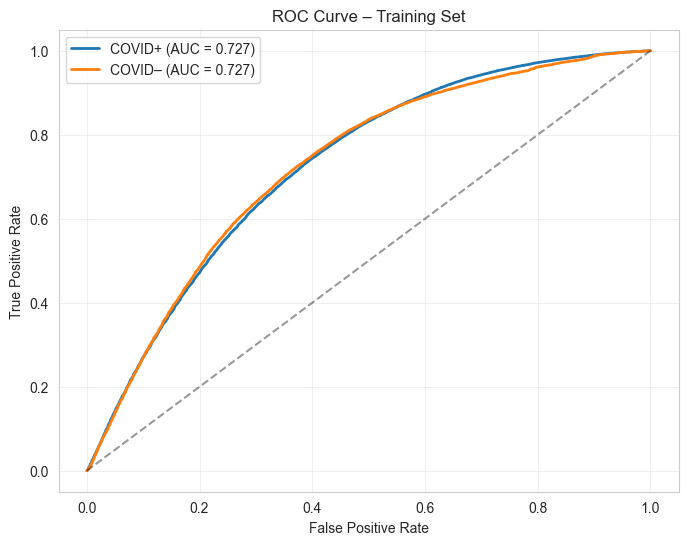

In [362]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Predicted probabilities for class 1 (death)
y_train_prob_pos = model_POS.predict_proba(X_train_pos)[:, 1]
y_train_prob_neg = model_NEG.predict_proba(X_train_neg)[:, 1]

# 2. ROC curves
fpr_pos, tpr_pos, _ = roc_curve(y_train_pos, y_train_prob_pos)
fpr_neg, tpr_neg, _ = roc_curve(y_train_neg, y_train_prob_neg)

auc_pos = auc(fpr_pos, tpr_pos)
auc_neg = auc(fpr_neg, tpr_neg)

# 3. Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_pos, tpr_pos, label=f"COVID+ (AUC = {auc_pos:.3f})", lw=2)
plt.plot(fpr_neg, tpr_neg, label=f"COVID– (AUC = {auc_neg:.3f})", lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


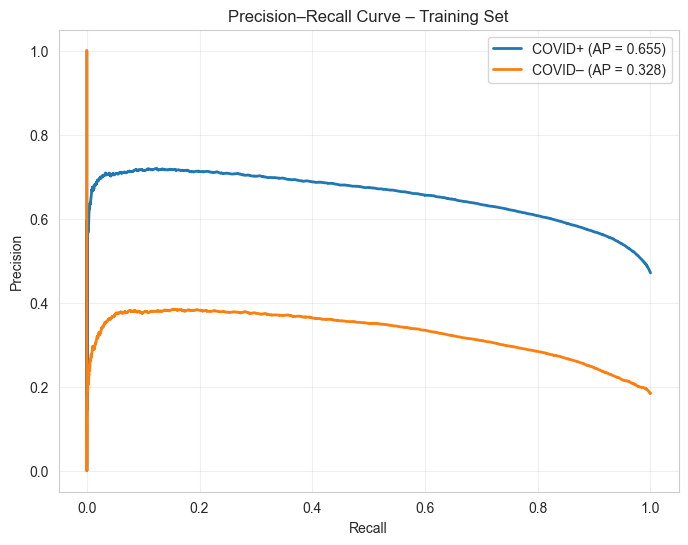

In [363]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. PR curves
prec_pos, rec_pos, _ = precision_recall_curve(y_train_pos, y_train_prob_pos)
prec_neg, rec_neg, _ = precision_recall_curve(y_train_neg, y_train_prob_neg)

ap_pos = average_precision_score(y_train_pos, y_train_prob_pos)
ap_neg = average_precision_score(y_train_neg, y_train_prob_neg)

# 2. Plot PR
plt.figure(figsize=(8, 6))
plt.plot(rec_pos, prec_pos, label=f"COVID+ (AP = {ap_pos:.3f})", lw=2)
plt.plot(rec_neg, prec_neg, label=f"COVID– (AP = {ap_neg:.3f})", lw=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


"Before applying any threshold optimization, both models demonstrate moderate ability to distinguish mortality outcomes, with the COVID‑positive model performing better. Precision–recall performance is modest in both groups, reflecting the clinical reality of imbalanced mortality outcomes. These baseline results justify the need for threshold optimization and further calibration to improve clinical usefulness."

## ROC and PR-CURVE OF TEST-SET

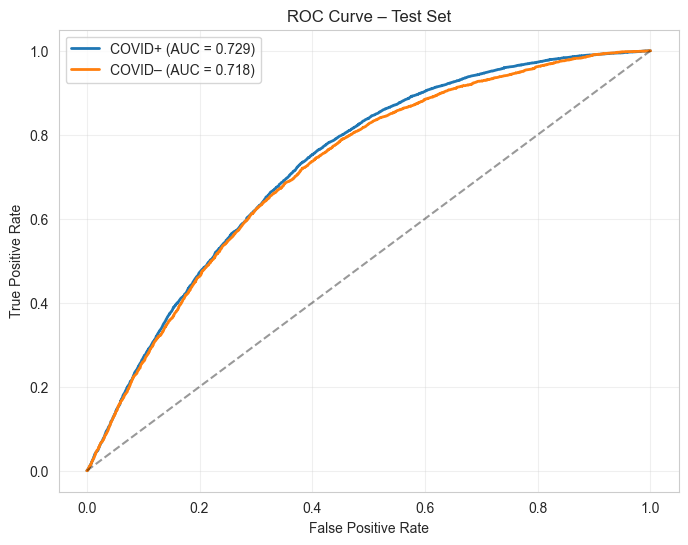

In [364]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Predicted probabilities for class 1 (death)
y_test_prob_pos = model_POS.predict_proba(X_test_pos)[:, 1]
y_test_prob_neg = model_NEG.predict_proba(X_test_neg)[:, 1]

# 2. ROC curves
fpr_pos, tpr_pos, _ = roc_curve(y_test_pos, y_test_prob_pos)
fpr_neg, tpr_neg, _ = roc_curve(y_test_neg, y_test_prob_neg)

auc_pos = auc(fpr_pos, tpr_pos)
auc_neg = auc(fpr_neg, tpr_neg)

# 3. Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_pos, tpr_pos, label=f"COVID+ (AUC = {auc_pos:.3f})", lw=2)
plt.plot(fpr_neg, tpr_neg, label=f"COVID– (AUC = {auc_neg:.3f})", lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


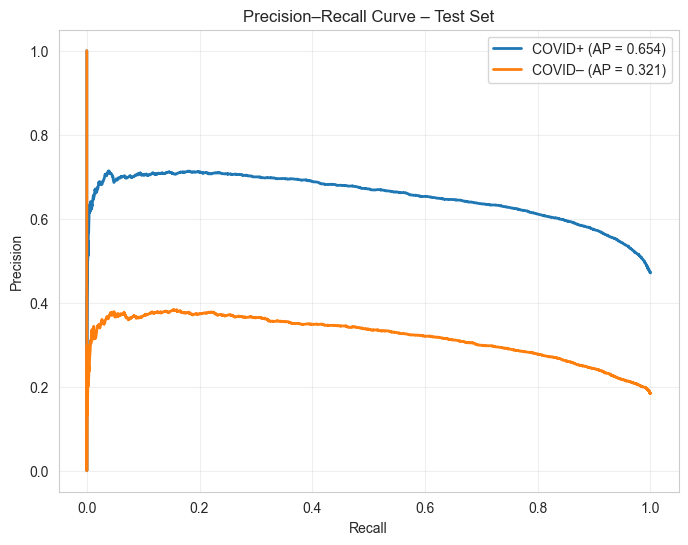

In [365]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. PR curves
prec_pos, rec_pos, _ = precision_recall_curve(y_test_pos, y_test_prob_pos)
prec_neg, rec_neg, _ = precision_recall_curve(y_test_neg, y_test_prob_neg)

ap_pos = average_precision_score(y_test_pos, y_test_prob_pos)
ap_neg = average_precision_score(y_test_neg, y_test_prob_neg)

# 2. Plot PR
plt.figure(figsize=(8, 6))
plt.plot(rec_pos, prec_pos, label=f"COVID+ (AP = {ap_pos:.3f})", lw=2)
plt.plot(rec_neg, prec_neg, label=f"COVID– (AP = {ap_neg:.3f})", lw=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


"The COVID‑positive model performs consistently better than the COVID‑negative model, especially in precision–recall space.
Both models generalize well to unseen data, but the severity and frequency of mortality in COVID‑positive patients makes their outcomes more predictable, while the extreme imbalance in the COVID‑negative group naturally leads to lower AP values."

## OR-TABLE 

In [366]:
OR_compare = or_df_POS.join(or_df_NEG, how="outer", lsuffix="_POS", rsuffix="_NEG")
OR_compare = OR_compare[["Feature_POS", "OR_POS", "OR_NEG"]]
OR_compare

,Feature_POS,OR_POS,OR_NEG
0,AGE,1.043708,1.031356
1,SEX,0.579474,0.579843
2,DIABETES,1.110215,1.144588
3,OBESITY,0.861503,0.678774
4,HIPERTENSION,0.937457,0.870824
5,CARDIOVASCULAR,0.506765,0.634721
6,COPD,0.635619,0.668788
7,ASTHMA,0.316018,0.225754
8,RENAL_CHRONIC,1.037386,1.100586
9,INMSUPR,0.629844,0.864820


"The odds ratios of the COVID‑positive and COVID‑negative models show similar overall patterns, but with meaningful differences in effect size. In both groups, AGE increases mortality risk (OR ≈ 1.03), while most comorbidities have OR values below 1, indicating weak or protective associations in this dataset. The COVID‑positive model generally shows slightly stronger effects for several variables (e.g., OBESITY, CARDIOVASCULAR, INMSUPR), whereas the COVID‑negative model shows higher ORs for DIABETES and RENAL_CHRONIC. Overall, both models exhibit low to moderate OR values, reflecting the relatively weak individual predictive power of single clinical features, with AGE remaining the most consistent risk factor across both groups."

In [367]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

def or_table_sm(X, y, label):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=0)

    params = model.params
    conf = model.conf_int()
    conf.columns = ["CI_lower", "CI_upper"]

    OR = np.exp(params)
    CI_lower = np.exp(conf["CI_lower"])
    CI_upper = np.exp(conf["CI_upper"])

    df = pd.DataFrame({
        "Variable": params.index,
        f"OR_{label}": OR,
        f"CI_lower_{label}": CI_lower,
        f"CI_upper_{label}": CI_upper
    })

    return df[df["Variable"] != "const"]  # Intercept entfernen

# Tabellen erstellen
or_POS = or_table_sm(X_train_pos, y_train_pos, "POS")
or_NEG = or_table_sm(X_train_neg, y_train_neg, "NEG")

# Zusammenführen
or_table = or_POS.merge(or_NEG, on="Variable")
or_table = or_table.sort_values("OR_POS", ascending=False)



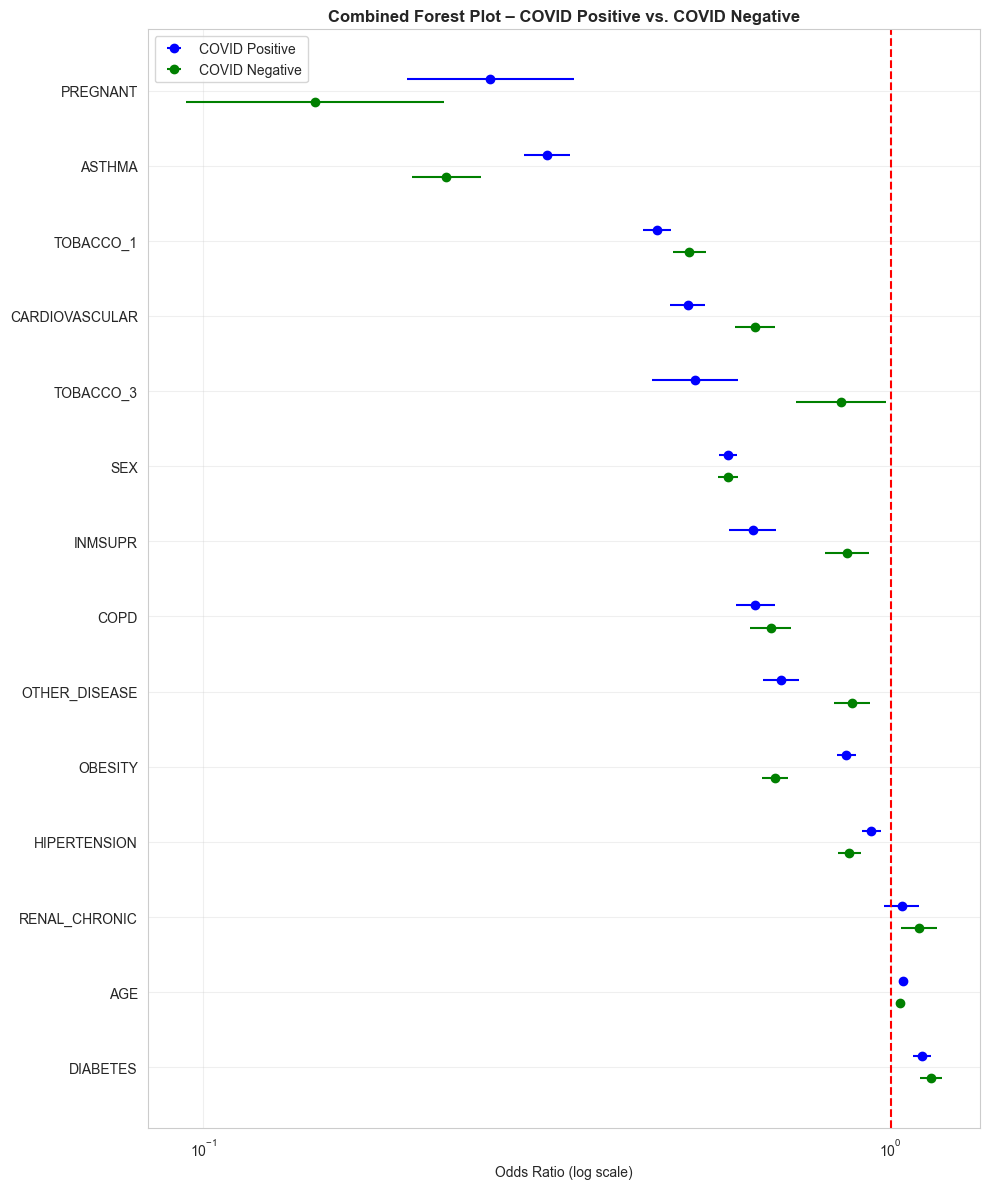

In [368]:
import matplotlib.pyplot as plt
import numpy as np

def combined_forest_plot(df):
    variables = df["Variable"]
    y = np.arange(len(variables))

    OR_pos = df["OR_POS"]
    CI_pos_low = df["CI_lower_POS"]
    CI_pos_up = df["CI_upper_POS"]

    OR_neg = df["OR_NEG"]
    CI_neg_low = df["CI_lower_NEG"]
    CI_neg_up = df["CI_upper_NEG"]

    plt.figure(figsize=(10, 12))

    # POS (blau)
    plt.errorbar(OR_pos, y + 0.15,
                 xerr=[OR_pos - CI_pos_low, CI_pos_up - OR_pos],
                 fmt='o', color="blue", label="COVID Positive")

    # NEG (grün)
    plt.errorbar(OR_neg, y - 0.15,
                 xerr=[OR_neg - CI_neg_low, CI_neg_up - OR_neg],
                 fmt='o', color="green", label="COVID Negative")

    plt.axvline(1, color='red', linestyle='--')
    plt.yticks(y, variables)
    plt.xscale("log")
    plt.xlabel("Odds Ratio (log scale)")
    plt.title("Combined Forest Plot – COVID Positive vs. COVID Negative", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

combined_forest_plot(or_table)


"The combined forest plot shows that the overall pattern of odds ratios is similar between COVID‑positive and COVID‑negative patients, but the strength of associations differs across conditions. In both groups, AGE is the only factor with an OR consistently above 1, confirming it as the most stable mortality risk factor. Most comorbidities show OR values below 1, indicating weak or protective associations in this dataset.

Several features display stronger effects in the COVID‑positive group, such as OBESITY, CARDIOVASCULAR disease, INMSUPR, and TOBACCO‑related variables, while DIABETES and RENAL_CHRONIC show slightly higher ORs in the COVID‑negative group. The tight clustering of ORs around 1 in both models highlights that no single comorbidity strongly predicts mortality, and the mortality signal is generally weak and diffuse, especially in COVID‑negative patients.

Overall, the forest plot confirms that age dominates risk, while other clinical features contribute only modestly and inconsistently across COVID‑positive and COVID‑negative populations."